# CELL 1 - Import và Cấu hình

In [1]:
import os
import glob
import csv
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Dropout, Flatten, BatchNormalization,
    Conv1D, MaxPooling1D, Bidirectional, Concatenate
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical


DATASET_PATH = "../DATASET_LABELED"
DATALABEL_PATH = "../DataLabel"
SAMPLE_RATE = 16000
DURATION = 4.0
N_MFCC = 20

EMOTION_MAP = {
    "ANG": 0,  # angry
    "ANX": 1,  # anxious
    "HAP": 2,  # happy
    "NEU": 3,  # neutral
    "SAD": 4   # sad
}

# Ánh xạ tên emotion trong CSV -> mã thư mục
EMOTION_CSV_TO_FOLDER = {
    "Anger": "ANG",
    "Anxiety": "ANX",
    "Happiness": "HAP",
    "Neutral": "NEU",
    "Sadness": "SAD"
}

GENDER_MAP = {
    "Nam": 0,
    "Nữ": 1
}

idx_to_emotion = {v: k for k, v in EMOTION_MAP.items()}

print("Đã import xong!")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "e:\anaconda3\envs\ser\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "e:\anaconda3\envs\ser\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "e:\anaconda3\envs\ser\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "e:\anaconda3\envs\ser\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "e:\anaconda3\envs\ser\lib\site-packages\ipykernel

AttributeError: _ARRAY_API not found

Đã import xong!


# CELL 2 - Hàm đọc metadata giới tính

In [2]:
def build_gender_lookup(datalabel_path):
    """
    Đọc tất cả file CSV trong DataLabel/ và xây dựng dict:
        {filename.wav: gender_value}  (0=Nam, 1=Nữ)
    Bỏ qua các dòng có Character=null hoặc rỗng.
    """
    gender_lookup = {}
    csv_files = glob.glob(os.path.join(datalabel_path, "*.csv"))

    for csv_file in csv_files:
        try:
            with open(csv_file, encoding='utf-8') as f:
                reader = csv.DictReader(f)
                for row in reader:
                    filename = row.get('Filename', '').strip()
                    character = row.get('Character', '').strip()

                    if not filename:
                        continue

                    # Bỏ qua nếu character là null hoặc rỗng
                    if character.lower() in ['null', '', 'none']:
                        continue

                    if character in GENDER_MAP:
                        gender_lookup[filename] = GENDER_MAP[character]
        except Exception as e:
            print(f"Lỗi đọc {csv_file}: {e}")

    return gender_lookup


print("\nĐang đọc metadata từ DataLabel/...")
gender_lookup = build_gender_lookup(DATALABEL_PATH)
print(f"Đã tìm thấy gender cho {len(gender_lookup)} file audio")

# Thống kê
nam_count = sum(1 for v in gender_lookup.values() if v == 0)
nu_count = sum(1 for v in gender_lookup.values() if v == 1)
print(f"  - Nam: {nam_count}")
print(f"  - Nữ: {nu_count}")



Đang đọc metadata từ DataLabel/...
Đã tìm thấy gender cho 1565 file audio
  - Nam: 752
  - Nữ: 813


# CELL 3 - Hàm Augmentation và Feature Extraction

In [3]:
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

def pad_audio(data, sr, duration=4.0):
    input_length = int(sr * duration)
    if len(data) > input_length:
        data = data[:input_length]
    else:
        padding = input_length - len(data)
        data = np.pad(data, (0, padding), 'constant')
    return data

def process_audio_file(file_path, augment=False):
    data, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    data, _ = librosa.effects.trim(data, top_db=25)

    if augment:
        choice = random.choice(['noise', 'stretch', 'shift', 'pitch'])
        if choice == 'noise': data = noise(data)
        elif choice == 'stretch': data = stretch(data)
        elif choice == 'shift': data = shift(data)
        elif choice == 'pitch': data = pitch(data, sr)

    data = pad_audio(data, sr, DURATION)
    return data

def extract_features(data, sr):
    zcr = librosa.feature.zero_crossing_rate(y=data, frame_length=2048, hop_length=512)
    rms = librosa.feature.rms(y=data, frame_length=2048, hop_length=512)
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=N_MFCC, hop_length=512)
    features = np.concatenate((zcr, rms, mfcc), axis=0)
    return features.T  # (126, 22)

print("Đã khai báo hàm trích xuất đặc trưng.")


Đã khai báo hàm trích xuất đặc trưng.


# CELL 4 - Load dữ liệu + Gender

In [4]:
X_audio = []
X_gender = []
y = []

print("\nĐang xử lý dữ liệu...")

skipped_no_gender = 0

for folder_name in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder_name)

    if os.path.isdir(folder_path) and folder_name in EMOTION_MAP:
        emotion_label = EMOTION_MAP[folder_name]
        print(f"-> Đang xử lý nhãn: {folder_name}")

        for file_path in glob.glob(os.path.join(folder_path, "*.wav")):
            basename = os.path.basename(file_path)

            # Tìm gender trong bảng tra cứu
            if basename not in gender_lookup:
                skipped_no_gender += 1
                continue

            gender_value = gender_lookup[basename]

            # 1. Lấy dữ liệu gốc (Original)
            sig = process_audio_file(file_path, augment=False)
            feat = extract_features(sig, SAMPLE_RATE)
            X_audio.append(feat)
            X_gender.append(gender_value)
            y.append(emotion_label)

            # 2. Tạo thêm dữ liệu giả (Augmentation)
            sig_aug = process_audio_file(file_path, augment=True)
            feat_aug = extract_features(sig_aug, SAMPLE_RATE)
            X_audio.append(feat_aug)
            X_gender.append(gender_value)  # Gender giữ nguyên
            y.append(emotion_label)

# Chuyển sang mảng Numpy
X_audio = np.array(X_audio)
X_gender = np.array(X_gender).reshape(-1, 1)  # Shape: (N, 1)
y = np.array(y)

# One-hot encoding cho nhãn
y_onehot = to_categorical(y, num_classes=5)

print(f"\nHoàn tất!")
print(f"Shape của X_audio: {X_audio.shape}")    # (N, 126, 22)
print(f"Shape của X_gender: {X_gender.shape}")  # (N, 1)
print(f"Shape của y: {y_onehot.shape}")          # (N, 5)
print(f"Số file bị bỏ qua (thiếu gender): {skipped_no_gender}")

# Thống kê gender trong dataset
print(f"\nThống kê gender trong dữ liệu training:")
print(f"  - Nam (0): {np.sum(X_gender == 0)} mẫu")
print(f"  - Nữ (1): {np.sum(X_gender == 1)} mẫu")



Đang xử lý dữ liệu...
-> Đang xử lý nhãn: ANG
-> Đang xử lý nhãn: ANX
-> Đang xử lý nhãn: HAP
-> Đang xử lý nhãn: NEU
-> Đang xử lý nhãn: SAD

Hoàn tất!
Shape của X_audio: (3052, 126, 22)
Shape của X_gender: (3052, 1)
Shape của y: (3052, 5)
Số file bị bỏ qua (thiếu gender): 148

Thống kê gender trong dữ liệu training:
  - Nam (0): 1490 mẫu
  - Nữ (1): 1562 mẫu


# CELL 5 - Chia Train/Test/Val

In [5]:
(X_audio_train, X_audio_test,
 X_gender_train, X_gender_test,
 y_train, y_test) = train_test_split(
    X_audio, X_gender, y_onehot, test_size=0.2, random_state=42
)

(X_audio_train, X_audio_val,
 X_gender_train, X_gender_val,
 y_train, y_val) = train_test_split(
    X_audio_train, X_gender_train, y_train, test_size=0.1, random_state=42
)

print(f"\nTrain samples: {X_audio_train.shape[0]}")
print(f"Validation samples: {X_audio_val.shape[0]}")
print(f"Test samples: {X_audio_test.shape[0]}")



Train samples: 2196
Validation samples: 245
Test samples: 611


# CELL 6 - Cấu hình và xây dựng Model Multi-Input

In [6]:
input_shape_audio = (X_audio_train.shape[1], X_audio_train.shape[2])  # (126, 22)
num_classes = 5

# ===========================================================================
# BƯỚC 6: XÂY DỰNG 3 MODEL MULTI-INPUT (Functional API)
# ===========================================================================

def build_gender_branch():
    """Nhánh xử lý gender (chung cho cả 3 model)"""
    gender_input = Input(shape=(1,), name='gender_input')
    g = Dense(16, activation='relu')(gender_input)
    g = Dense(8, activation='relu')(g)
    return gender_input, g


# ----------- MODEL 1: Multi-Input LSTM -----------
def build_multi_input_lstm(input_shape, num_classes):
    # Nhánh Audio
    audio_input = Input(shape=input_shape, name='audio_input')
    x = LSTM(128, return_sequences=True)(audio_input)
    x = Dropout(0.3)(x)
    x = LSTM(64)(x)
    x = Dropout(0.3)(x)
    audio_features = Dense(64, activation='relu')(x)

    # Nhánh Gender
    gender_input, gender_features = build_gender_branch()

    # Gộp 2 nhánh
    concat = Concatenate()([audio_features, gender_features])
    z = Dense(64, activation='relu')(concat)
    z = Dropout(0.3)(z)
    output = Dense(num_classes, activation='softmax', name='output')(z)

    model = Model(inputs=[audio_input, gender_input], outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# ----------- MODEL 2: Multi-Input Bi-LSTM -----------
def build_multi_input_bilstm(input_shape, num_classes):
    # Nhánh Audio
    audio_input = Input(shape=input_shape, name='audio_input')
    x = Bidirectional(LSTM(64, return_sequences=True))(audio_input)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.3)(x)
    audio_features = Dense(64, activation='relu')(x)

    # Nhánh Gender
    gender_input, gender_features = build_gender_branch()

    # Gộp 2 nhánh
    concat = Concatenate()([audio_features, gender_features])
    z = Dense(64, activation='relu')(concat)
    z = Dropout(0.3)(z)
    output = Dense(num_classes, activation='softmax', name='output')(z)

    model = Model(inputs=[audio_input, gender_input], outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# ----------- MODEL 3: Multi-Input CNN -----------
def build_multi_input_cnn(input_shape, num_classes):
    # Nhánh Audio
    audio_input = Input(shape=input_shape, name='audio_input')
    x = Conv1D(64, kernel_size=5, activation='relu', padding='same')(audio_input)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Flatten()(x)
    audio_features = Dense(128, activation='relu')(x)

    # Nhánh Gender
    gender_input, gender_features = build_gender_branch()

    # Gộp 2 nhánh
    concat = Concatenate()([audio_features, gender_features])
    z = Dense(64, activation='relu')(concat)
    z = Dropout(0.3)(z)
    output = Dense(num_classes, activation='softmax', name='output')(z)

    model = Model(inputs=[audio_input, gender_input], outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# CELL 7 - Train Model 1: Multi-Input LSTM

In [7]:
rlrop = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Dữ liệu train chung
train_inputs = [X_audio_train, X_gender_train]
val_data = ([X_audio_val, X_gender_val], y_val)
test_inputs = [X_audio_test, X_gender_test]

model_lstm = build_multi_input_lstm(input_shape_audio, num_classes)
print(model_lstm.summary())

history_lstm = model_lstm.fit(
    train_inputs, y_train,
    epochs=50, batch_size=32,
    validation_data=val_data,
    callbacks=[rlrop, early_stopping])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 126, 22)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 126, 128)  │     77,312 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 126, 128)  │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         32 │ gender_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        136 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,672 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 136,045 (531.43 KB)

 Trainable params: 136,045 (531.43 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4437 - loss: 1.4389 - val_accuracy: 0.5429 - val_loss: 1.2518 - learning_rate: 0.0010
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5268 - loss: 1.3305 - val_accuracy: 0.5592 - val_loss: 1.2190 - learning_rate: 0.0010
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5753 - loss: 1.2071 - val_accuracy: 0.5592 - val_loss: 1.2250 - learning_rate: 0.0010
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5648 - loss: 1.1878 - val_accuracy: 0.5755 - val_loss: 1.1782 - learning_rate: 0.0010
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5739 - loss: 1.1365 - val_accuracy: 0.5714 - val_loss: 1.1728 - learning_rate: 0.0010
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.5995 - loss: 1.1100 - val_accuracy: 0.5592 - val_loss: 1.2098 - learning_rate: 0.0010
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.6242 - loss: 1.0905 - va

# CELL 8 - Train Model 2: Multi-Input Bi-LSTM

In [8]:
rlrop = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

model_bilstm = build_multi_input_bilstm(input_shape_audio, num_classes)

history_bilstm = model_bilstm.fit(
    train_inputs, y_train,
    epochs=50, batch_size=32,
    validation_data=val_data,
    callbacks=[rlrop, early_stopping])


Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.4181 - loss: 1.4635 - val_accuracy: 0.5224 - val_loss: 1.2843 - learning_rate: 0.0010
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5202 - loss: 1.2966 - val_accuracy: 0.5429 - val_loss: 1.2303 - learning_rate: 0.0010
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5452 - loss: 1.2433 - val_accuracy: 0.5796 - val_loss: 1.1796 - learning_rate: 0.0010
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5663 - loss: 1.1949 - val_accuracy: 0.6163 - val_loss: 1.1385 - learning_rate: 0.0010
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5820 - loss: 1.1206 - val_accuracy: 0.6122 - val_loss: 1.1060 - learning_rate: 0.0010
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6264 - loss: 1.0337 - val_accuracy: 0.6163 - val_loss: 1.1118 - learning_rate: 0.0010
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6423 - loss: 0.9973 - val_acc

# CELL 9 - Train Model 3: Multi-Input CNN

In [9]:
rlrop = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

model_cnn = build_multi_input_cnn(input_shape_audio, num_classes)

history_cnn = model_cnn.fit(
    train_inputs, y_train,
    epochs=50, batch_size=32,
    validation_data=val_data,
    callbacks=[rlrop, early_stopping])


Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4248 - loss: 1.7725 - val_accuracy: 0.5388 - val_loss: 1.2323 - learning_rate: 0.0010
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5613 - loss: 1.2056 - val_accuracy: 0.5510 - val_loss: 1.2019 - learning_rate: 0.0010
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6045 - loss: 1.0823 - val_accuracy: 0.5633 - val_loss: 1.1380 - learning_rate: 0.0010
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6613 - loss: 0.9070 - val_accuracy: 0.5020 - val_loss: 1.2608 - learning_rate: 0.0010
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7062 - loss: 0.8038 - val_accuracy: 0.5714 - val_loss: 1.1611 - learning_rate: 0.0010
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7705 - loss: 0.6839 - val_accuracy: 0.6041 - val_loss: 1.0781 - learning_rate: 0.0010
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7940 - loss: 0.5881 - val_accuracy:

# CELL 10 - So sánh và đánh giá kết quả


SO SÁNH KẾT QUẢ CÁC MODEL (VỚI ĐẶC TRƯNG GIỚI TÍNH)

LSTM + Gender:
  Test Loss: 0.9231
  Test Accuracy: 70.54%

Bi-LSTM + Gender:
  Test Loss: 0.9796
  Test Accuracy: 64.98%

CNN + Gender:
  Test Loss: 0.8772
  Test Accuracy: 70.21%

SO SÁNH VỚI KẾT QUẢ CŨ (KHÔNG CÓ GENDER)
  LSTM (cũ): 67.71% → LSTM + Gender: 70.54% (↑ 2.83%)
  Bi-LSTM (cũ): 69.64% → Bi-LSTM + Gender: 64.98% (↓ 4.66%)
  CNN (cũ): 61.01% → CNN + Gender: 70.21% (↑ 9.20%)

🏆 MODEL TỐT NHẤT: LSTM + Gender với accuracy 70.54%


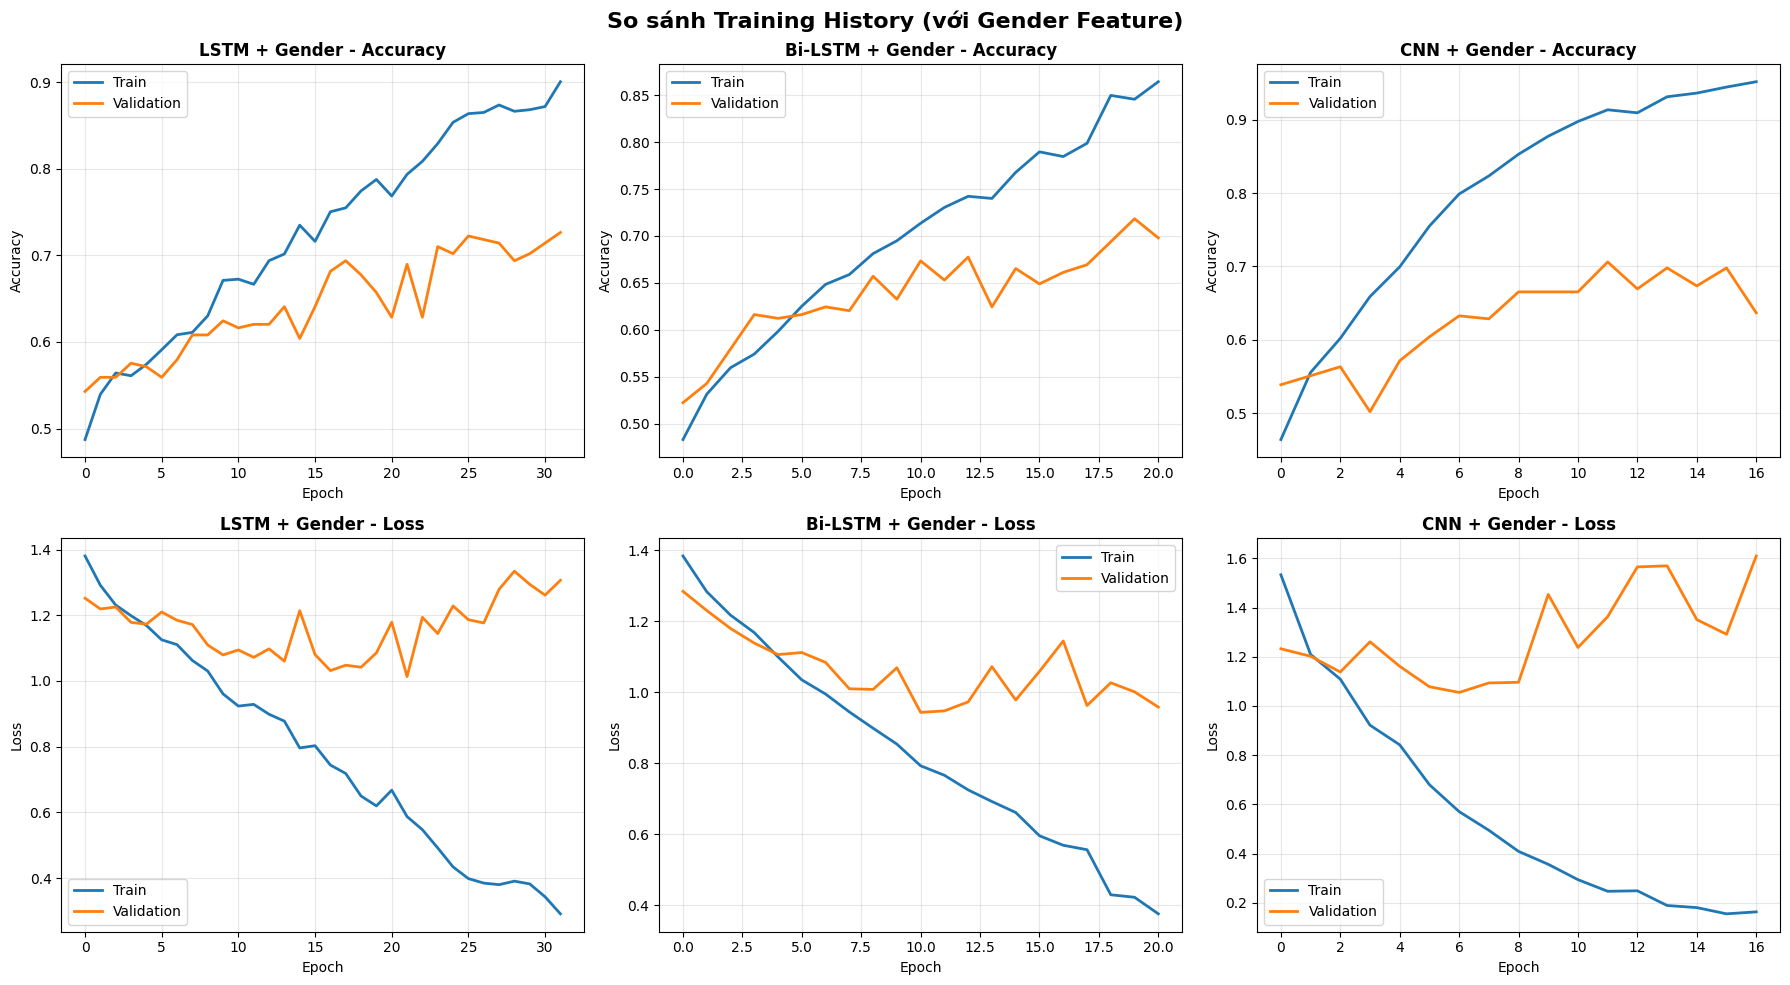

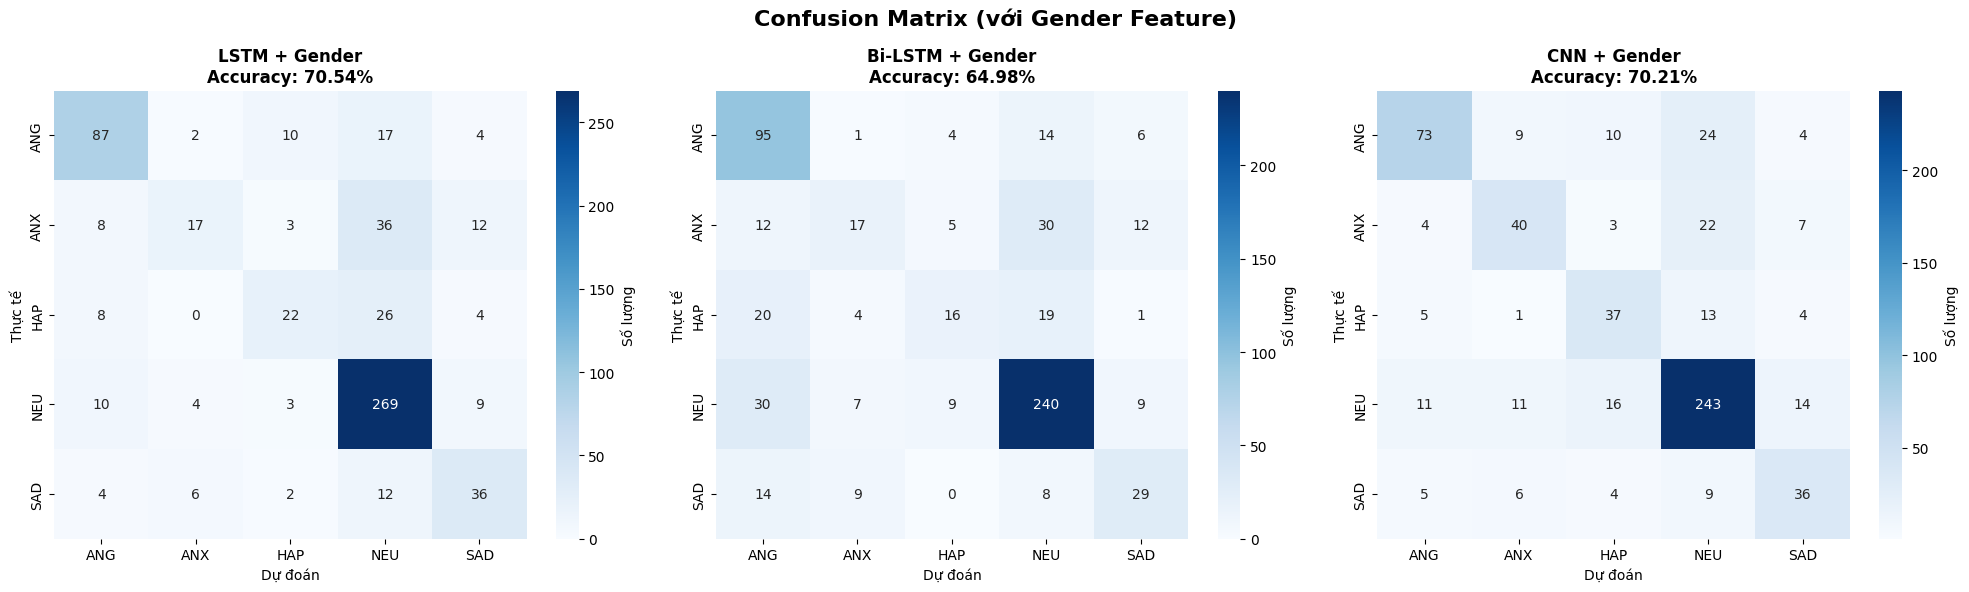


CLASSIFICATION REPORT CHO LSTM + Gender (Model tốt nhất)
              precision    recall  f1-score   support

         ANG     0.7436    0.7250    0.7342       120
         ANX     0.5862    0.2237    0.3238        76
         HAP     0.5500    0.3667    0.4400        60
         NEU     0.7472    0.9119    0.8214       295
         SAD     0.5538    0.6000    0.5760        60

    accuracy                         0.7054       611
   macro avg     0.6362    0.5654    0.5791       611
weighted avg     0.6881    0.7054    0.6808       611


🏁 Training hoàn tất!


In [10]:
models = {
    'LSTM + Gender': (model_lstm, history_lstm),
    'Bi-LSTM + Gender': (model_bilstm, history_bilstm),
    'CNN + Gender': (model_cnn, history_cnn)
}

print("\n" + "=" * 60)
print("SO SÁNH KẾT QUẢ CÁC MODEL (VỚI ĐẶC TRƯNG GIỚI TÍNH)")
print("=" * 60)

results = {}
for model_name, (model, history) in models.items():
    loss, acc = model.evaluate(test_inputs, y_test, verbose=0)
    results[model_name] = {'loss': loss, 'accuracy': acc}
    print(f"\n{model_name}:")
    print(f"  Test Loss: {loss:.4f}")
    print(f"  Test Accuracy: {acc*100:.2f}%")

# So sánh với kết quả cũ (không có gender)
print("\n" + "=" * 60)
print("SO SÁNH VỚI KẾT QUẢ CŨ (KHÔNG CÓ GENDER)")
print("=" * 60)
old_results = {
    'LSTM (cũ)': 67.71,
    'Bi-LSTM (cũ)': 69.64,
    'CNN (cũ)': 61.01
}

new_names = ['LSTM + Gender', 'Bi-LSTM + Gender', 'CNN + Gender']
old_names = ['LSTM (cũ)', 'Bi-LSTM (cũ)', 'CNN (cũ)']

for new_n, old_n in zip(new_names, old_names):
    old_acc = old_results[old_n]
    new_acc = results[new_n]['accuracy'] * 100
    diff = new_acc - old_acc
    arrow = "↑" if diff > 0 else ("↓" if diff < 0 else "=")
    print(f"  {old_n}: {old_acc:.2f}% → {new_n}: {new_acc:.2f}% ({arrow} {abs(diff):.2f}%)")

# Tìm model tốt nhất
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print("\n" + "=" * 60)
print(f"🏆 MODEL TỐT NHẤT: {best_model_name} với accuracy {results[best_model_name]['accuracy']*100:.2f}%")
print("=" * 60)

# ===========================================================================
# BƯỚC 9: VẼ ĐỒ THỊ
# ===========================================================================
# 1. Vẽ đồ thị Loss và Accuracy cho cả 3 model
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('So sánh Training History (với Gender Feature)', fontsize=16, fontweight='bold')

for idx, (model_name, (model, history)) in enumerate(models.items()):
    axes[0, idx].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0, idx].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    axes[0, idx].set_title(f'{model_name} - Accuracy', fontweight='bold')
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Accuracy')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

    axes[1, idx].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1, idx].plot(history.history['val_loss'], label='Validation', linewidth=2)
    axes[1, idx].set_title(f'{model_name} - Loss', fontweight='bold')
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Loss')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_with_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Vẽ Confusion Matrix cho cả 3 model
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix (với Gender Feature)', fontsize=16, fontweight='bold')

for idx, (model_name, (model, history)) in enumerate(models.items()):
    y_pred = model.predict(test_inputs, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=list(EMOTION_MAP.keys()),
                yticklabels=list(EMOTION_MAP.keys()),
                cbar_kws={'label': 'Số lượng'})
    axes[idx].set_title(f'{model_name}\nAccuracy: {results[model_name]["accuracy"]*100:.2f}%',
                        fontweight='bold')
    axes[idx].set_xlabel('Dự đoán')
    axes[idx].set_ylabel('Thực tế')

plt.tight_layout()
plt.savefig('confusion_matrix_with_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Classification Report cho model tốt nhất
print("\n" + "=" * 60)
print(f"CLASSIFICATION REPORT CHO {best_model_name} (Model tốt nhất)")
print("=" * 60)
best_model = models[best_model_name][0]
y_pred_best = best_model.predict(test_inputs, verbose=0)
y_pred_classes_best = np.argmax(y_pred_best, axis=1)
y_true_best = np.argmax(y_test, axis=1)

print(classification_report(y_true_best, y_pred_classes_best,
                          target_names=list(EMOTION_MAP.keys()),
                          digits=4))

print("\n🏁 Training hoàn tất!")
